In [4]:
# ============================================================
# Fine-Tuning-PS-LLM
# Notebook: 07_results_analysis.ipynb
# Purpose: Analyze and compare Baseline, SFT, and DPO models.
# ============================================================

In [5]:
# ============================================================
# Fine-Tuning-PS-LLM
# Notebook: 07_results_analysis.ipynb
# Section: Mount Google Drive
# Purpose: Mount Google Drive to access project files.
# ============================================================

from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# ============================================================
# Fine-Tuning-PS-LLM
# Notebook: 07_results_analysis.ipynb
# Section: Import Libraries
# Purpose: Import required libraries.
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

In [7]:
# ============================================================
# Fine-Tuning-PS-LLM
# Notebook: 07_results_analysis.ipynb
# Section: Configure Project Paths
# Purpose: Define project directories.
# ============================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Colab Notebooks/Fine-Tuning-PS-LLM"
)

RESULTS_DIR = PROJECT_ROOT / "results"

FIGURES_DIR = PROJECT_ROOT / "figures"

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(PROJECT_ROOT)
print(RESULTS_DIR)
print(FIGURES_DIR)

/content/drive/MyDrive/Colab Notebooks/Fine-Tuning-PS-LLM
/content/drive/MyDrive/Colab Notebooks/Fine-Tuning-PS-LLM/results
/content/drive/MyDrive/Colab Notebooks/Fine-Tuning-PS-LLM/figures


In [8]:
# ============================================================
# Fine-Tuning-PS-LLM
# Notebook: 07_results_analysis.ipynb
# Section: Load Prediction Files
# Purpose: Load Baseline, SFT, and DPO predictions.
# ============================================================

baseline_df = pd.read_csv(
    RESULTS_DIR
    / "baseline"
    / "baseline_predictions.csv"
)

sft_df = pd.read_csv(
    RESULTS_DIR
    / "sft"
    / "sft_predictions.csv"
)

dpo_df = pd.read_csv(
    RESULTS_DIR
    / "dpo"
    / "dpo_predictions.csv"
)

print(f"Baseline : {len(baseline_df)}")
print(f"SFT      : {len(sft_df)}")
print(f"DPO      : {len(dpo_df)}")

Baseline : 12
SFT      : 12
DPO      : 12


In [9]:
# ============================================================
# Fine-Tuning-PS-LLM
# Notebook: 07_results_analysis.ipynb
# Section: Verify Evaluation Dataset
# Purpose: Ensure all models were evaluated on the same dataset.
# ============================================================

assert len(baseline_df) == len(sft_df) == len(dpo_df)

assert (
    baseline_df["quote_id"].tolist()
    ==
    sft_df["quote_id"].tolist()
    ==
    dpo_df["quote_id"].tolist()
)

assert (
    baseline_df["gold_category"].tolist()
    ==
    sft_df["gold_category"].tolist()
    ==
    dpo_df["gold_category"].tolist()
)

print("✓ Same evaluation dataset confirmed.")
print(f"Samples: {len(baseline_df)}")

✓ Same evaluation dataset confirmed.
Samples: 12


In [10]:
# ============================================================
# Fine-Tuning-PS-LLM
# Notebook: 07_results_analysis.ipynb
# Section: Compute Evaluation Metrics
# Purpose: Compute evaluation metrics for all models.
# ============================================================

MODELS = {
    "Baseline": baseline_df,
    "SFT": sft_df,
    "DPO": dpo_df,
}

metrics = []

for model_name, df in MODELS.items():

    accuracy = accuracy_score(
        df["gold_category"],
        df["predicted_category"],
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            df["gold_category"],
            df["predicted_category"],
            average="macro",
            zero_division=0,
        )
    )

    weighted_precision, weighted_recall, weighted_f1, _ = (
        precision_recall_fscore_support(
            df["gold_category"],
            df["predicted_category"],
            average="weighted",
            zero_division=0,
        )
    )

    metrics.append(
        {
            "Model": model_name,
            "Accuracy": accuracy,
            "Macro Precision": precision,
            "Macro Recall": recall,
            "Macro F1": f1,
            "Weighted Precision": weighted_precision,
            "Weighted Recall": weighted_recall,
            "Weighted F1": weighted_f1,
        }
    )

metrics_df = pd.DataFrame(metrics)

metrics_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0,Baseline,0.250000,0.066667,0.200000,0.100000,0.083333,0.250000,0.125000
1,SFT,0.500000,0.675000,0.516667,0.489091,0.760417,0.500000,0.478030
2,DPO,0.833333,0.520000,0.600000,0.550000,0.733333,0.833333,0.770833


In [20]:
# ============================================================
# Fine-Tuning-PS-LLM
# Notebook: 07_results_analysis.ipynb
# Section: Save Evaluation Metrics
# Purpose: Save evaluation metrics as CSV.
# ============================================================

metrics_path = RESULTS_DIR / "metrics_summary.csv"

metrics_df.to_csv(
    metrics_path,
    index=False,
)

print("Metrics saved to:")
print(metrics_path)

metrics_df

Metrics saved to:
/content/drive/MyDrive/Colab Notebooks/Fine-Tuning-PS-LLM/results/metrics_summary.csv


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0,Baseline,0.250000,0.066667,0.200000,0.100000,0.083333,0.250000,0.125000
1,SFT,0.500000,0.675000,0.516667,0.489091,0.760417,0.500000,0.478030
2,DPO,0.833333,0.520000,0.600000,0.550000,0.733333,0.833333,0.770833


In [12]:
# ============================================================
# Fine-Tuning-PS-LLM
# Notebook: 07_results_analysis.ipynb
# Section: Generate Comparison Table
# Purpose: Compare predictions from all evaluated models.
# ============================================================

In [22]:
# ============================================================
# Fine-Tuning-PS-LLM
# Notebook: 07_results_analysis.ipynb
# Section: Generate Comparison Table
# Purpose: Compare predictions from all evaluated models.
# ============================================================

comparison = pd.DataFrame({

    "Quote ID": baseline_df["quote_id"],

    "Gold Category": baseline_df["gold_category"],

    "Baseline Prediction": baseline_df["predicted_category"],

    "SFT Prediction": sft_df["predicted_category"],

    "DPO Prediction": dpo_df["predicted_category"],

})

comparison["Baseline Correct"] = (
    comparison["Gold Category"]
    ==
    comparison["Baseline Prediction"]
)

comparison["SFT Correct"] = (
    comparison["Gold Category"]
    ==
    comparison["SFT Prediction"]
)

comparison["DPO Correct"] = (
    comparison["Gold Category"]
    ==
    comparison["DPO Prediction"]
)

comparison_path = RESULTS_DIR / "comparison.csv"

comparison.to_csv(
    comparison_path,
    index=False,
)

print("Comparison table saved:")
print(comparison_path)

comparison

Comparison table saved:
/content/drive/MyDrive/Colab Notebooks/Fine-Tuning-PS-LLM/results/comparison.csv


,Quote ID,Gold Category,Baseline Prediction,SFT Prediction,DPO Prediction,Baseline Correct,SFT Correct,DPO Correct
0,Quote 71,Disagreeing with suggestions/ideas,Drawing attention to errors,Disagreeing with suggestions/ideas,Disagreeing with suggestions/ideas,False,True,True
1,Quote 57,Expressing concerns,Expressing concerns,Expressing concerns,Expressing concerns,True,True,True
2,Quote 84,Seeking help,Expressing concerns,Seeking help,Expressing concerns,False,True,False
3,Quote 110,Disagreeing with suggestions/ideas,Expressing concerns,Expressing concerns,Disagreeing with suggestions/ideas,False,False,True
4,Quote 27,Recommending changes,Expressing concerns,Expressing concerns,Recommending changes,False,False,True
5,Quote 12,Disagreeing with suggestions/ideas,Drawing attention to errors,Expressing concerns,Disagreeing with suggestions/ideas,False,False,True
6,Quote 54,Expressing concerns,Expressing concerns,Expressing concerns,Expressing concerns,True,True,True
7,Quote 05,Recommending changes,Expressing concerns,Expressing concerns,Recommending changes,False,False,True
8,Quote 89,Recommending changes,Expressing concerns,Recommending changes,Recommending changes,False,True,True
9,Quote 48,Disagreeing with suggestions/ideas,Drawing attention to errors,Drawing attention to errors,Disagreeing with suggestions/ideas,False,False,True


In [21]:
# ============================================================
# Fine-Tuning-PS-LLM
# Notebook: 07_results_analysis.ipynb
# Section: Analyze Prediction Errors
# Purpose: Save incorrect predictions.
# ============================================================

errors = comparison.loc[
    ~comparison["Baseline Correct"],
    [
        "Quote ID",
        "Gold Category",
        "Baseline Prediction",
        "SFT Prediction",
        "DPO Prediction",
    ],
]

errors_path = RESULTS_DIR / "errors.csv"

errors.to_csv(
    errors_path,
    index=False,
)

print("Errors saved:")
print(errors_path)

errors

Errors saved:
/content/drive/MyDrive/Colab Notebooks/Fine-Tuning-PS-LLM/results/errors.csv


,Quote ID,Gold Category,Baseline Prediction,SFT Prediction,DPO Prediction
0,Quote 71,Disagreeing with suggestions/ideas,Drawing attention to errors,Disagreeing with suggestions/ideas,Disagreeing with suggestions/ideas
2,Quote 84,Seeking help,Expressing concerns,Seeking help,Expressing concerns
3,Quote 110,Disagreeing with suggestions/ideas,Expressing concerns,Expressing concerns,Disagreeing with suggestions/ideas
4,Quote 27,Recommending changes,Expressing concerns,Expressing concerns,Recommending changes
5,Quote 12,Disagreeing with suggestions/ideas,Drawing attention to errors,Expressing concerns,Disagreeing with suggestions/ideas
7,Quote 05,Recommending changes,Expressing concerns,Expressing concerns,Recommending changes
8,Quote 89,Recommending changes,Expressing concerns,Recommending changes,Recommending changes
9,Quote 48,Disagreeing with suggestions/ideas,Drawing attention to errors,Drawing attention to errors,Disagreeing with suggestions/ideas
10,Quote 43,Drawing attention to errors,Expressing concerns,Expressing concerns,Expressing concerns


In [24]:
# ============================================================
# Fine-Tuning-PS-LLM
# Notebook: 07_results_analysis.ipynb
# Section: Classification Reports
# Purpose: Generate detailed evaluation reports.
# ============================================================

reports = []

for model_name, df in MODELS.items():

    report = classification_report(
        df["gold_category"],
        df["predicted_category"],
        output_dict=True,
        zero_division=0,
    )

    report_df = pd.DataFrame(report).transpose()

    report_df["Model"] = model_name

    reports.append(report_df)

reports_df = pd.concat(
    reports,
    ignore_index=False,
)

reports_path = RESULTS_DIR / "classification_reports.csv"

reports_df.to_csv(
    reports_path,
)

print("Classification reports saved:")
print(reports_path)

reports_df

Classification reports saved:
/content/drive/MyDrive/Colab Notebooks/Fine-Tuning-PS-LLM/results/classification_reports.csv


,precision,recall,f1-score,support,Model
Disagreeing with suggestions/ideas,0.000000,0.000000,0.000000,4.000000,Baseline
Drawing attention to errors,0.000000,0.000000,0.000000,1.000000,Baseline
Expressing concerns,0.333333,1.000000,0.500000,3.000000,Baseline
Recommending changes,0.000000,0.000000,0.000000,3.000000,Baseline
Seeking help,0.000000,0.000000,0.000000,1.000000,Baseline
accuracy,0.250000,0.250000,0.250000,0.250000,Baseline
macro avg,0.066667,0.200000,0.100000,12.000000,Baseline
weighted avg,0.083333,0.250000,0.125000,12.000000,Baseline
Disagreeing with suggestions/ideas,1.000000,0.250000,0.400000,4.000000,SFT
Drawing attention to errors,0.000000,0.000000,0.000000,1.000000,SFT


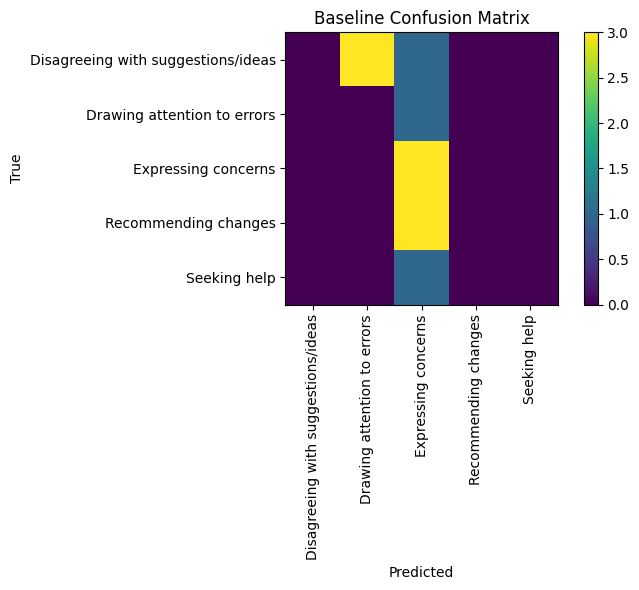

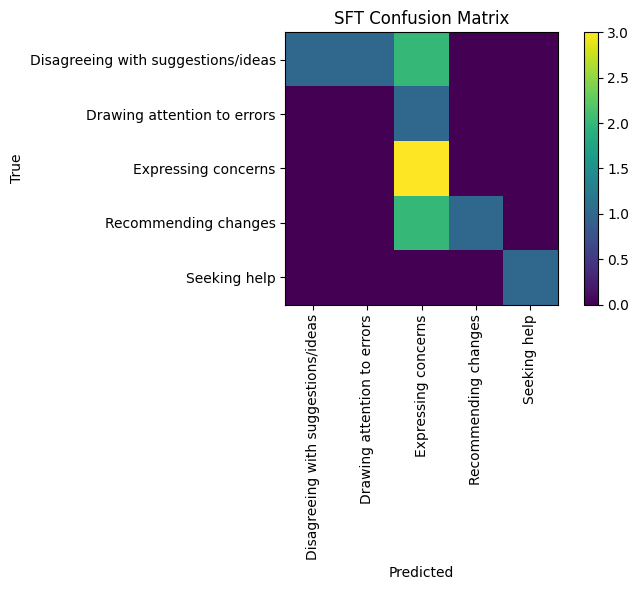

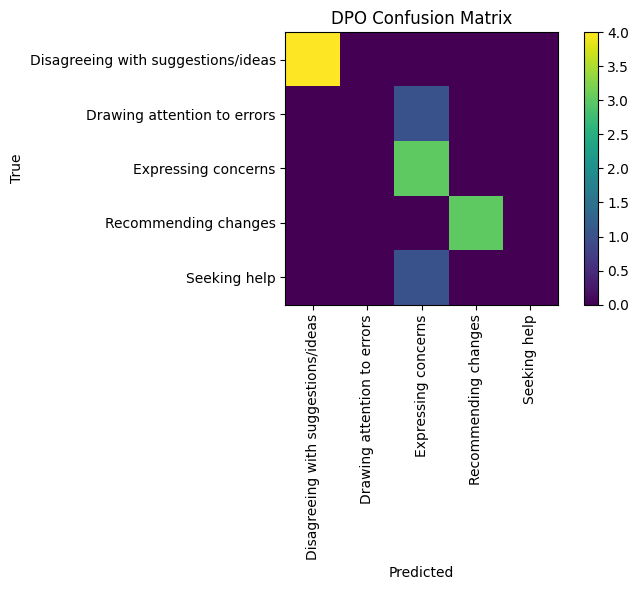

In [16]:
# ============================================================
# Fine-Tuning-PS-LLM
# Notebook: 07_results_analysis.ipynb
# Section: Confusion Matrices
# Purpose: Generate and save confusion matrices.
# ============================================================

labels = sorted(
    baseline_df["gold_category"].unique()
)

for model_name, df in MODELS.items():

    cm = confusion_matrix(
        df["gold_category"],
        df["predicted_category"],
        labels=labels,
    )

    plt.figure(figsize=(8,6))

    plt.imshow(cm)

    plt.title(f"{model_name} Confusion Matrix")

    plt.colorbar()

    plt.xticks(
        range(len(labels)),
        labels,
        rotation=90,
    )

    plt.yticks(
        range(len(labels)),
        labels,
    )

    plt.xlabel("Predicted")

    plt.ylabel("True")

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR /
        f"{model_name.lower()}_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    plt.close()

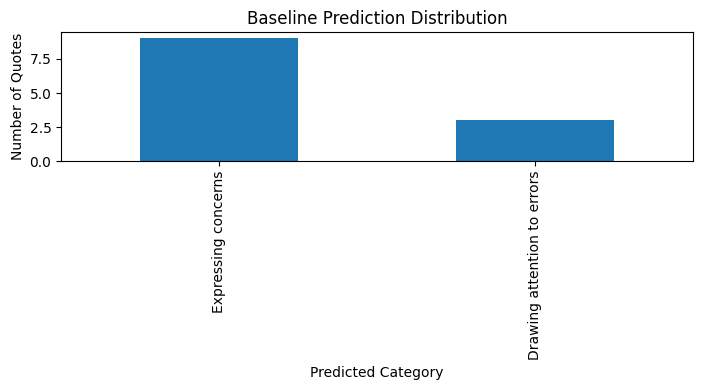

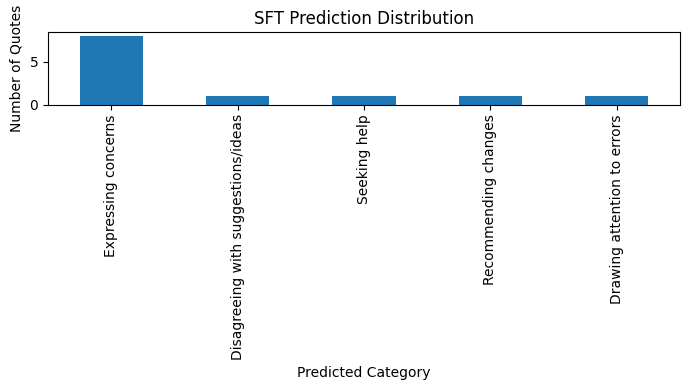

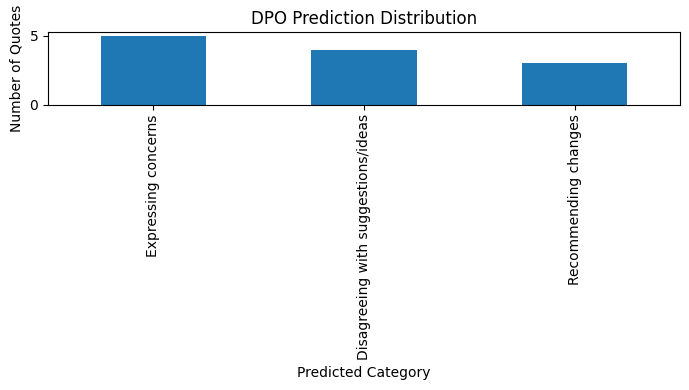

In [17]:
# ============================================================
# Fine-Tuning-PS-LLM
# Notebook: 07_results_analysis.ipynb
# Section: Prediction Distribution
# Purpose: Visualize predicted category distribution.
# ============================================================

for model_name, df in MODELS.items():

    plt.figure(figsize=(7,4))

    df["predicted_category"].value_counts().plot(
        kind="bar"
    )

    plt.title(
        f"{model_name} Prediction Distribution"
    )

    plt.xlabel("Predicted Category")

    plt.ylabel("Number of Quotes")

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR /
        f"{model_name.lower()}_prediction_distribution.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    plt.close()

<Figure size 800x500 with 0 Axes>

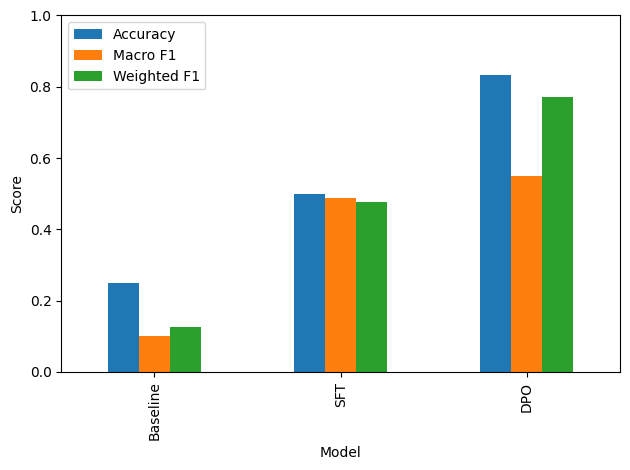

In [18]:
# ============================================================
# Fine-Tuning-PS-LLM
# Notebook: 07_results_analysis.ipynb
# Section: Metrics Comparison
# Purpose: Compare overall model performance.
# ============================================================

plt.figure(figsize=(8,5))

metrics_plot = metrics_df.set_index("Model")[
    [
        "Accuracy",
        "Macro F1",
        "Weighted F1",
    ]
]

metrics_plot.plot(
    kind="bar"
)

plt.ylabel("Score")

plt.ylim(0,1)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "metrics_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

plt.close()

In [19]:
# ============================================================
# Fine-Tuning-PS-LLM
# Notebook: 07_results_analysis.ipynb
# Section: Analysis Summary
# Purpose: Display generated analysis artifacts.
# ============================================================

print("=" * 70)
print("Analysis Completed Successfully")
print("=" * 70)

print()

print("Results Directory")
print(RESULTS_DIR)

print()

print("Figures Directory")
print(FIGURES_DIR)

print()

print("Generated CSV Files")

for file in sorted(RESULTS_DIR.glob("*.csv")):
    print(" •", file.name)

print()

print("Generated Figures")

for file in sorted(FIGURES_DIR.glob("*.png")):
    print(" •", file.name)

print()

print("Notebook finished successfully.")

Analysis Completed Successfully

Results Directory
/content/drive/MyDrive/Colab Notebooks/Fine-Tuning-PS-LLM/results

Figures Directory
/content/drive/MyDrive/Colab Notebooks/Fine-Tuning-PS-LLM/figures

Generated CSV Files
 • classification_reports.csv
 • comparison.csv
 • errors.csv
 • metrics_summary.csv

Generated Figures
 • baseline_confusion_matrix.png
 • baseline_prediction_distribution.png
 • dpo_confusion_matrix.png
 • dpo_prediction_distribution.png
 • metrics_comparison.png
 • sft_confusion_matrix.png
 • sft_prediction_distribution.png

Notebook finished successfully.
